In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display

In [41]:
def plotAudio2(sig,sampleRate,title):
  time=np.arange(0,sig.shape[0])/sampleRate


   # Scale the y-axis to represent amplitude from -1 to 1
  excursion=max(abs(sig))
  sigNew = sig / excursion


   # Label the x and y axes with variables
  xlabel = 'Time (seconds)'
  ylabel = 'Amplitude'


   #plot the signal using the x and y axis variables
  plt.plot(time,sigNew)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(title)
  plt.show()
    # from Assignment 2/Google Doc


In [84]:
def plotAudioFreqDomain(sig,sr,title,winSize,specType):
    # create a normalized spectrogram
    # this includes several function calls
    # first create a basic specgrogram with librosa.stft() with the default window size (2048)
    # then make all of values in the spectrogram positive with np.abs()
    # then scale the spectogram to be in decibels, so it better reflects how we hear librosa.amplitude_to_db()
    spec = librosa.amplitude_to_db(np.abs(librosa.stft(sig,n_fft=winSize)), ref=np.max)
    # display the normalized spectrogram with a log frequency scale
    librosa.display.specshow(spec, y_axis=specType)
    plt.colorbar(format='%+2.0f dB')
    plt.title('Linear-frequency power spectrogram')
    plt.show()
    # from Assignment 3

In [7]:
def additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent):
    # generate list of harmonics
    harmonics = np.arange(1,numHarmonics+1,seqHarm)

    # create a time series from 0 to 1 the inputted length
    timeSeries = np.linspace(0, 1, samplingRate)

    # create a cosine wave for the fundamental
    signal = np.cos(2.0 * np.pi * frequency * timeSeries)

    # add harmonics based on the those specified in the variable 'harmonics'
    for harm in harmonics:
        signal = signal + np.cos(2.0 * np.pi * frequency * harm * timeSeries)/harm**ampExponent

    # scale the signal to between -1 and 1
    excursion=max(abs(signal))
    signal = signal / excursion

    # plot signal
    plt.plot(timeSeries,signal)
    plt.xlabel('Time (Sec)')
    plt.ylabel('Amplitude')
    plt.title('Additive Synthesis')
    plt.plot

    return signal
   # from additiveSynthesis.ipynb

In [25]:
def makeWaveforms(frequency,samplingRate,numHarmonics,waveType):
    # use an if/elif/else statement to set up the parameters for
    # the different type of waveforms based on the code in
    # additiveSynthesis.ipynb
    # if, elif (else if) and else can be used to evaluate the contents of a variable
  if waveType == 'sawtooth':
       seqHarm = 1
       ampExponent = 1
  elif waveType == 'square':
       seqHarm = 2
       ampExponent = 1
  elif waveType == 'triangle':
       seqHarm = 2
       ampExponent = 2
  else:
        numHarmonics = 1
        seqHarm = 1
        ampExponent = 1

  signal = additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent)

# play signal
  return signal

    # call additiveSynthesis() to generate a waveform

    # return the generated waveform (signal)



In [73]:
def visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType, winSize):
  # call makeWaveform()
  # test whether makeWaveforms() runs without error before you try plotting anything
  title=waveType
  sig = makeWaveforms(frequency, samplingRate, numHarmonics, waveType)
  # call plotAudio2()
  plotAudio2(sig,samplingRate,title)
  # call plotAudioFreqDomain()
  plotAudioFreqDomain(sig,samplingRate,title,winSize,specType)
  # return the output of makeWaveform()
  return sig

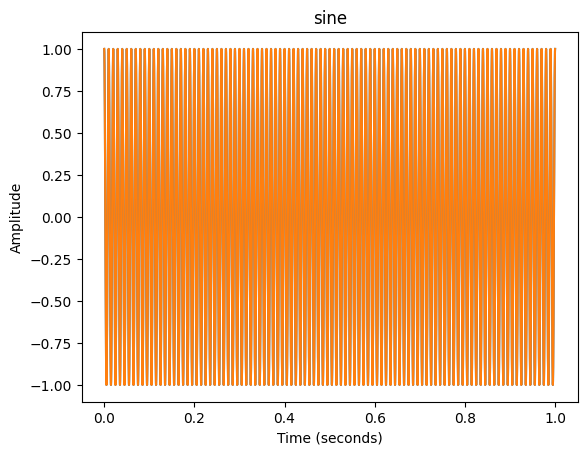

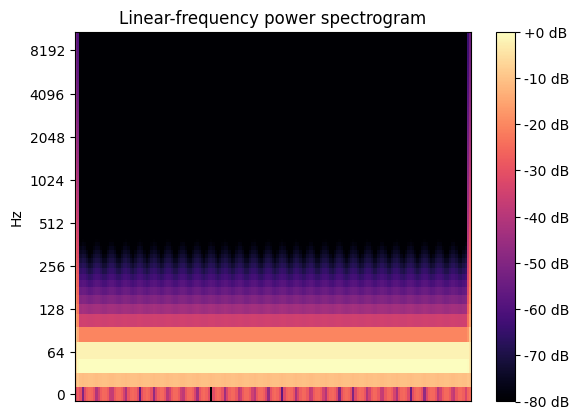

array([1.        , 0.9998985 , 0.99959402, ..., 0.99959402, 0.9998985 ,
       1.        ])

In [85]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'sine'
winSize = 1024
specType = 'log'

visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType, winSize)

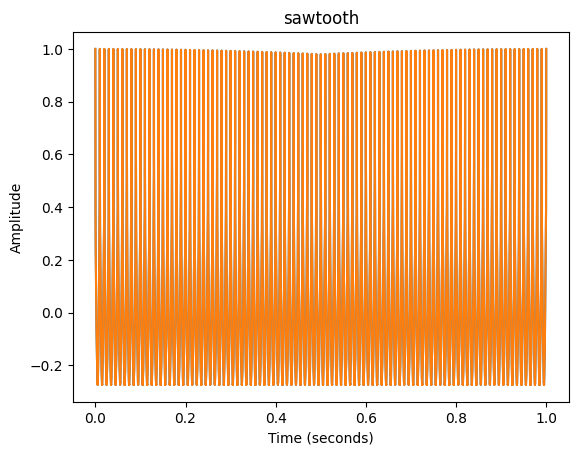

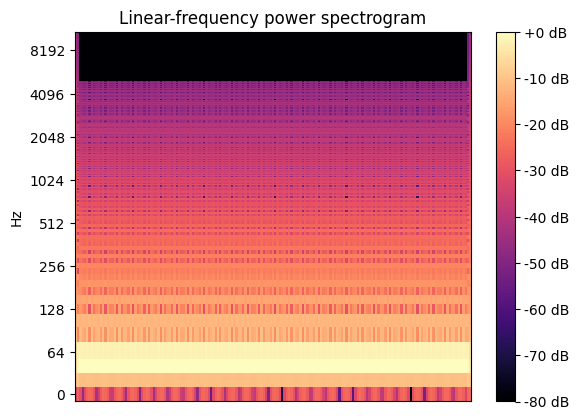

array([1.        , 0.92390394, 0.76327164, ..., 0.76327164, 0.92390394,
       1.        ])

In [86]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'sawtooth'
winSize = 1024
specType = 'log'

visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType, winSize)

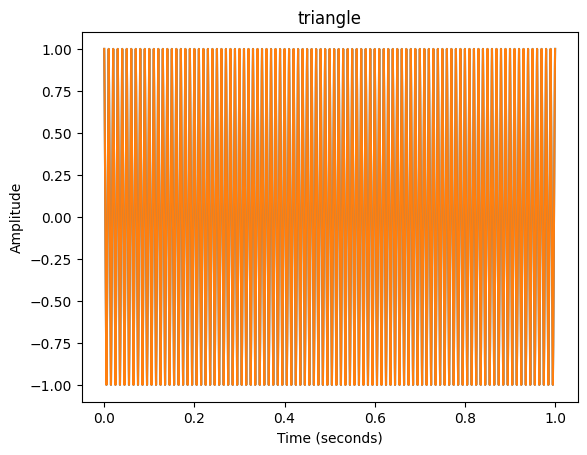

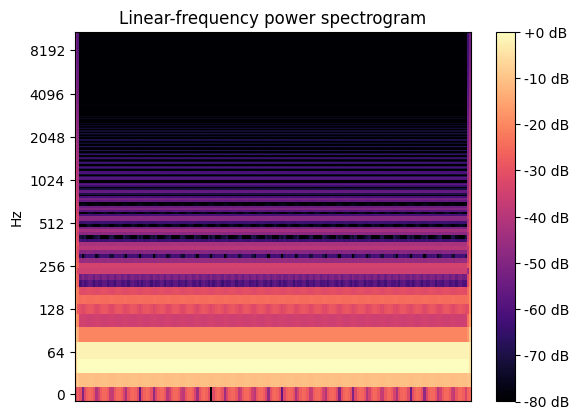

array([1.        , 0.99780063, 0.99246226, ..., 0.99246226, 0.99780063,
       1.        ])

In [87]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'triangle'
winSize = 1024
specType = 'log'

visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType, winSize)

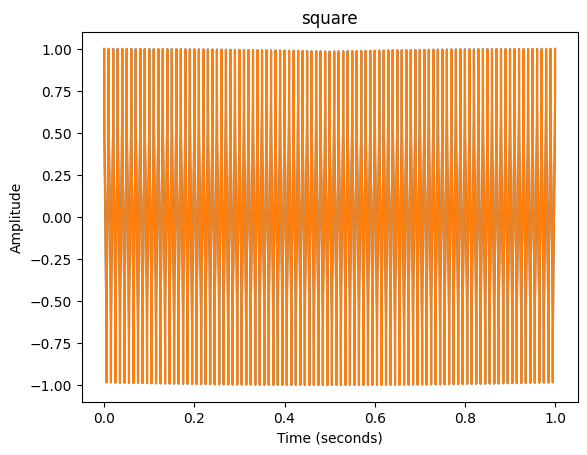

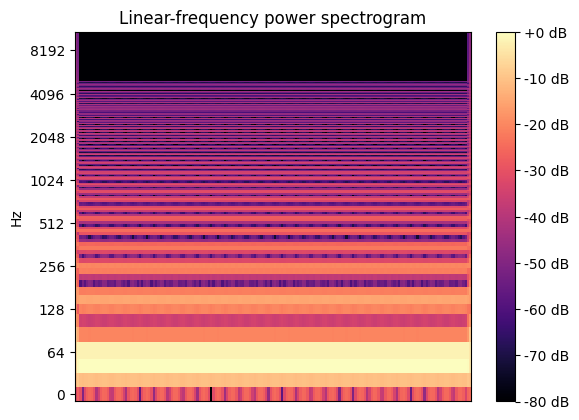

array([1.        , 0.94074376, 0.81519064, ..., 0.81519064, 0.94074376,
       1.        ])

In [88]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'square'
winSize = 1024
specType = 'log'

visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType, winSize)